# SRP — Sequential Residual Predictor
Weak MLP ensemble + causal attention + diversity loss

In [1]:
# Install dependencies

# Upload weak_learners.py, diversity.py, srp_model.py, train.py to Colab
# then run this cell to make them importable
import sys, os
sys.path.insert(0, '/content/')
print('Setup complete.')

Setup complete.


In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing, load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from srp_model import SRPModel
# from diversity import diversity_loss, cosine_similarity_matrix, pearson_correlation_matrix
from train import train
from sklearn.preprocessing import QuantileTransformer

import importlib
import train  # the name of your file, train.py
import srp_model

# Force Python to reload the files from disk
importlib.reload(train)
importlib.reload(srp_model)

# Now import the specific function/class
from train import train
from srp_model import SRPModel

## 1. Load Dataset

In [3]:
TASK = 'regression'   # 'regression' or 'classification'

if TASK == 'regression':
    data = fetch_california_housing()
    X, y = data.data, data.target.astype(np.float32)
else:
    data = load_wine()
    X, y = data.data.astype(np.float32), data.target

# scaler = StandardScaler()
# X = scaler.fit_transform(X).astype(np.float32)

scaler = QuantileTransformer(
    output_distribution='normal',
    n_quantiles= 1000,
    random_state=42
    )
X = scaler.fit_transform(X).astype(np.float32)


X_tr, X_val, y_tr, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

X_tr  = torch.tensor(X_tr)
X_val = torch.tensor(X_val)
y_tr  = torch.tensor(y_tr)  if TASK == 'regression' else torch.tensor(y_tr, dtype=torch.long)
y_val = torch.tensor(y_val) if TASK == 'regression' else torch.tensor(y_val, dtype=torch.long)

print(f'Train: {X_tr.shape}, Val: {X_val.shape}')

Train: torch.Size([16512, 8]), Val: torch.Size([4128, 8])


## 2. Build & Train Model

In [4]:
INPUT_DIM   = X_tr.shape[1]
NUM_LEARNERS = 8
HIDDEN_DIM   = 8      # 4-16
EMBED_DIM    = 16     # output dim of each weak learner
DEPTH        = 1      # 1 or 2
OUTPUT_DIM   = 1 if TASK == 'regression' else len(np.unique(y_tr.numpy()))

model = SRPModel(
    input_dim=INPUT_DIM,
    num_learners=NUM_LEARNERS,
    hidden_dim=HIDDEN_DIM,
    embed_dim=EMBED_DIM,
    depth=DEPTH,
    num_heads=2,
    output_dim=OUTPUT_DIM,
    task=TASK
)

# history = train(
#     model, X_tr, y_tr, X_val, y_val,
#     epochs=100,
#     lr=1e-3,
#     batch_size=64,
#     diversity_weight=0.1,
#     diversity_mode='combined',   # 'cosine' | 'correlation' | 'combined'
#     l1_lambda=1e-4,
#     l2_lambda=1e-4
# )

history = train(
    model, X_tr, y_tr, X_val, y_val,
    epochs=100,
    lr=1e-3,
    batch_size=64,
    l1_lambda=1e-4,
    l2_lambda=1e-4
)

Epoch  10 | train_loss=0.3352 | val_loss=0.3180
Epoch  20 | train_loss=0.2992 | val_loss=0.3049
Epoch  30 | train_loss=0.2816 | val_loss=0.2905
Epoch  40 | train_loss=0.2695 | val_loss=0.2810
Epoch  50 | train_loss=0.2617 | val_loss=0.2738
Epoch  60 | train_loss=0.2532 | val_loss=0.2612
Epoch  70 | train_loss=0.2465 | val_loss=0.2665
Epoch  80 | train_loss=0.2424 | val_loss=0.2623
Epoch  90 | train_loss=0.2400 | val_loss=0.2580
Epoch 100 | train_loss=0.2351 | val_loss=0.2532


## 3. Training Curves

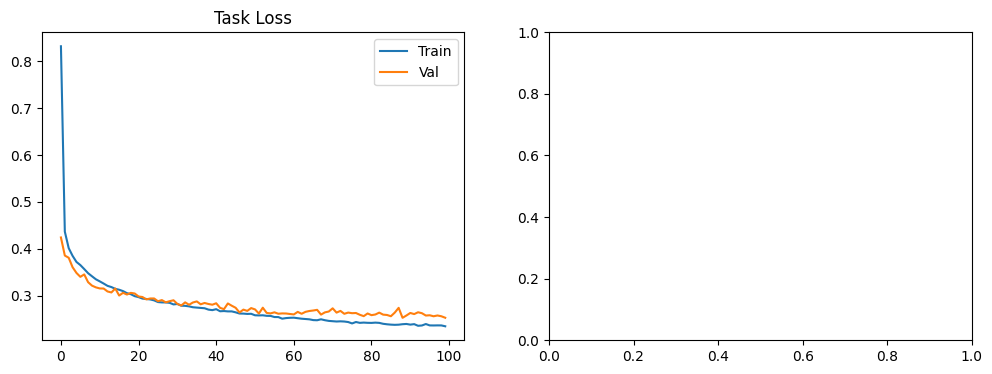

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history['train_loss'], label='Train')
axes[0].plot(history['val_loss'],   label='Val')
axes[0].set_title('Task Loss'); axes[0].legend()

# axes[1].plot(history['diversity'], color='orange')
# axes[1].set_title('Diversity Loss (lower = more diverse)')

# plt.tight_layout(); plt.show()

## 4. Diversity Visualization — Similarity Matrix

In [6]:
# model.eval()
# with torch.no_grad():
#     _, features, attn_weights = model(X_val[:200])

# _, cos_matrix  = cosine_similarity_matrix(features)
# _, corr_matrix = pearson_correlation_matrix(features)

# fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# sns.heatmap(cos_matrix.cpu().numpy(),  annot=True, fmt='.2f', ax=axes[0],
#             vmin=-1, vmax=1, cmap='coolwarm', square=True)
# axes[0].set_title('Cosine Similarity Matrix')

# sns.heatmap(corr_matrix.cpu().numpy(), annot=True, fmt='.2f', ax=axes[1],
#             vmin=-1, vmax=1, cmap='coolwarm', square=True)
# axes[1].set_title('Pearson Correlation Matrix')

# plt.tight_layout(); plt.show()
# print(f'Mean off-diag cosine sim : {cos_matrix.fill_diagonal_(0).abs().mean():.4f}')
# print(f'Mean off-diag correlation: {corr_matrix.fill_diagonal_(0).abs().mean():.4f}')

## 5. Attention Weights Visualization

In [7]:
# attn_weights: (B, K+1, K+1) — averaged over heads by nn.MultiheadAttention
avg_attn = attn_weights.mean(dim=0).cpu().numpy()   # (K+1, K+1)

labels = [f'MLP{i}' for i in range(NUM_LEARNERS)]

plt.figure(figsize=(8, 6))
sns.heatmap(avg_attn, xticklabels=labels, yticklabels=labels,
            annot=True, fmt='.2f', cmap='Blues', square=True)
plt.title('Causal Attention Weights (avg over batch)')
plt.tight_layout(); plt.show()

NameError: name 'attn_weights' is not defined

## 6. Ablation — Diversity Weight Effect

In [ ]:
results = {}
for dw in [0.0, 0.05, 0.1, 0.5, 1.0]:
    m = SRPModel(INPUT_DIM, NUM_LEARNERS, HIDDEN_DIM, EMBED_DIM, DEPTH,
                 num_heads=2, output_dim=OUTPUT_DIM, task=TASK)
    h = train(m, X_tr, y_tr, X_val, y_val, epochs=50, lr=1e-3,
              diversity_weight=dw, diversity_mode='combined',
              l1_lambda=1e-4, l2_lambda=1e-4)
    results[dw] = h['val_loss'][-1]
    print(f'div_weight={dw:.2f} -> val_loss={results[dw]:.4f}')

plt.bar([str(k) for k in results], results.values())
plt.xlabel('Diversity Weight'); plt.ylabel('Val Loss')
plt.title('Effect of Diversity Weight on Validation Loss')
plt.show()